# ODE symmetry detection examples

Interactive notebook version of `examples/plot_ode_manifold.py` (manifold + normal
field plots) combined with `examples/run_odes_demo.py` (basis-function symmetry
detection), built entirely on the public `symmetry_detection` API — no logic is
duplicated here.

Workflow:
1. Trajectory generation always uses the package defaults for the chosen ODE
   (`generate_trajectories.ODE_DEFAULTS`, via `resolve_ode_args`) — that part is
   intentionally not tunable here, to keep this notebook focused on basis/symmetry
   tuning. Use `examples/run_odes_demo.py --start ... --end ...` etc. if you need
   to control integration settings too.
2. `BASIS_TYPE` / `PARAM_RANGE` / `PARAM_LIST` can be changed and re-run from the
   **Symmetry detection** section onward, without regenerating trajectories. This
   solves the SVD but deliberately does *not* pick a singular vector yet.
3. Only after the small singular value candidates are printed do you set
   `SV_CHOICE` (in the **Choose which singular vector to use** cell) and
   reconstruct from it — that choice is never forced upfront.

## 1. Trajectory generation

Select the ODE example you would like to test. Uses the package-wide defaults for the chosen ODE (via `resolve_ode_args`) —
not tunable here by design; only `ODE` above affects this.

ODE= 'bernoulli'


       ODE Configuration — BERNOULLI        
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter        ┃ Value                 ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ X Range          │ [0.2, 1.2]            │
│ Resolution       │ 30 points/trajectory  │
│ Trajectory Count │ 10 initial conditions │
│ IC Range         │ [0.75 ... 2.00]       │
│ Integrator       │ RK45                  │
└──────────────────┴───────────────────────┘

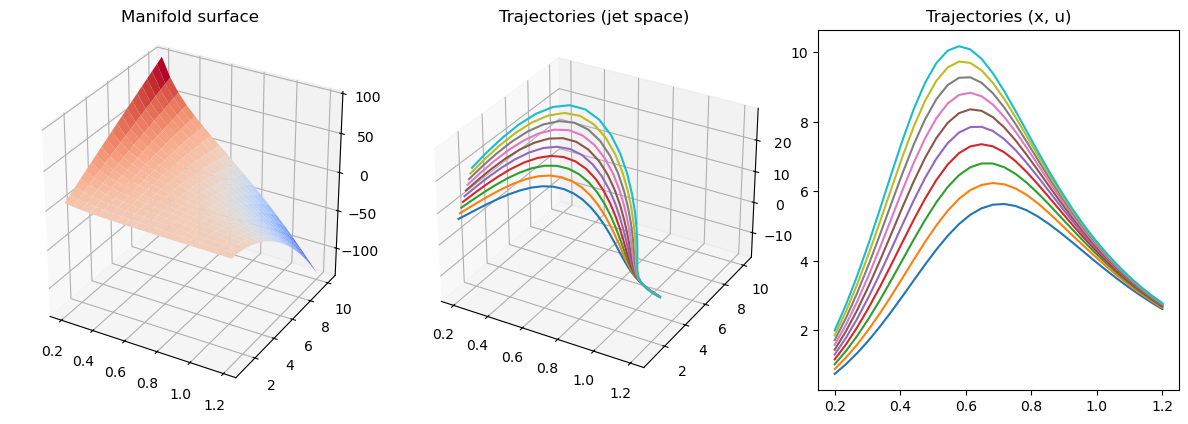

In [1]:

import argparse

import numpy as np
from matplotlib import pyplot as plt

from symmetry_detection import data_matrices as dm
from symmetry_detection import generate_trajectories as gtr
from symmetry_detection import plotting as plot
from symmetry_detection import reporting as rpt
from symmetry_detection import solver

%matplotlib inline

# --- ODE choice ---
# One of gtr.ODES.keys(): "bernoulli", "rational", "riccati", "scaling", "abel"
ODE = "bernoulli"

print(f"ODE= {ODE!r}")

# Reuse the same resolution function the CLI/example scripts use, so this
# notebook can never disagree with them about what "default" means.
ode_args = argparse.Namespace(
    ode=ODE, start=None, end=None, initial_conditions=None, num_points=None, method=None,
)
ode_args = gtr.resolve_ode_args(ode_args)

X = gtr.generate_equation_manifold(
    ode_name=ode_args.ode,
    x_start=ode_args.start,
    x_end=ode_args.end,
    initial_conditions=ode_args.initial_conditions,
    num_points=ode_args.num_points,
    method=ode_args.method,
)
X_stacked = gtr.concatenate_trajectories(X)
N = gtr.NORMALS[ode_args.ode](X_stacked[0], X_stacked[1])

# Plot the generated trajectories
# Grid of values of the surface manifold over [x_min, x_max] x [u_min, u_max]
x_min, x_max = np.min(X[:, 0, :]), np.max(X[:, 0, :])
u_min, u_max = np.min(X[:, 1, :]), np.max(X[:, 1, :])

res = 20
X_grid = np.linspace(x_min, x_max, res)
U_grid = np.linspace(u_min, u_max, res)
X_grid, U_grid = np.meshgrid(X_grid, U_grid)
P_grid = gtr.ODES[ode_args.ode](X_grid, U_grid)
p_grid_min, p_grid_max = np.min(P_grid), np.max(P_grid)

# Manifold surface, jet-space trajectories, and (x, u) trajectories side by side
manifold_fig = plt.figure(figsize=(12, 4))
ax0 = manifold_fig.add_subplot(131, projection='3d')
ax1 = manifold_fig.add_subplot(132, projection='3d')
ax2 = manifold_fig.add_subplot(133)

ax0.set_aspect('equal')
ax2.set_box_aspect(1)

ax0.plot_surface(X_grid, U_grid, P_grid, cmap='coolwarm')
ax0.set_title("Manifold surface")

for trajectory in X:
    ax1.plot(trajectory[0, :], trajectory[1, :], trajectory[2, :])
    ax2.plot(trajectory[0, :], trajectory[1, :])

ax1.set_title("Trajectories (jet space)")
ax2.set_title("Trajectories (x, u)")
manifold_fig.tight_layout()

## 2. Symmetry detection

(equivalent to `examples/run_odes_demo.py`)

Change `BASIS_TYPE`, `PARAM_RANGE`, or `PARAM_LIST` below and re-run from here
— the trajectories generated above are reused as-is. This first solves the
SVD; it does **not** decide which singular value(s) are "small" or which one
to reconstruct from — that's a separate, explicit choice made further down,
once you can see the results.

Estimated null-space dimension: 3
Small singular value indices: [29, 30, 31]


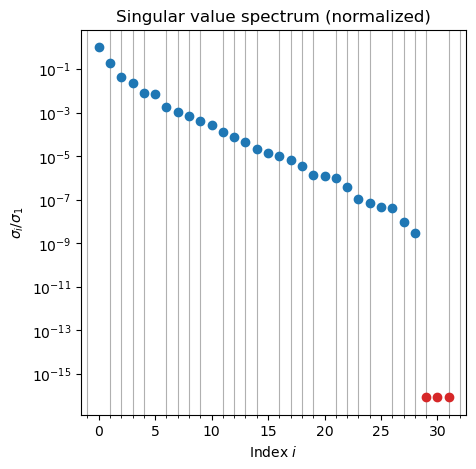

In [2]:
# --- Basis function family ---
# "monomial" or "chebyshev" (see symmetry_detection.basis_functions.BASIS_FUNCTIONS)
BASIS_TYPE = "monomial"

# --- Basis elements: pick a range OR an explicit list, exactly like the CLI's
# --param_range / --param_list flags (see data_matrices.resolve_basis_args).
# PARAM_LIST always overrides PARAM_RANGE when it is not None.
PARAM_RANGE = (0, 3)  # all (m, n) pairs with m, n in 0..3
PARAM_LIST = None     # e.g. [(0, 0), (1, 0), (0, 1), (2, 1)] to pick elements individually
sv_ratio = 100

# Resolve basis parameters the same way the CLI does: PARAM_LIST overrides
# PARAM_RANGE, and any still-missing field falls back to symmetry_detection.defaults.
basis_args = argparse.Namespace(
    basis_type=BASIS_TYPE,
    param_range=list(PARAM_RANGE) if PARAM_RANGE is not None else None,
    param_list=PARAM_LIST,
)
basis_args = dm.resolve_basis_args(basis_args)

# Build the homogeneous system and solve its null space via SVD. This is
# pure linear algebra: solve_svd makes no judgment about which singular
# value(s) are "small" - that's a separate, explicit step below, done only
# after you can see svd_result.S here.
svd_result = solver.solve_svd(
    X_stacked, N,
    basis_type=basis_args.basis_type,
    param_range=basis_args.param_range,
    param_list=basis_args.param_list,
)
small_sv_idx = solver.small_singular_value_indices(svd_result.S, drop_ratio=sv_ratio)
rpt.print_svd_summary(svd_result.S, small_sv_idx)

S_norm = svd_result.S / svd_result.S[0]
all_idx = np.arange(len(svd_result.S))
large_sv_idx = np.setdiff1d(all_idx, small_sv_idx, assume_unique=True)

fig3, ax3 = plt.subplots(figsize=(5, 5))

ax3.semilogy(large_sv_idx, S_norm[large_sv_idx], marker='o', linestyle='None', color='C0')
ax3.semilogy(small_sv_idx, S_norm[small_sv_idx], marker='o', linestyle='None', color='C3')
ax3.set_xlabel("Index $i$")
ax3.set_ylabel(r"$\sigma_i / \sigma_1$")
ax3.set_title("Singular value spectrum (normalized)")
ax3.set_box_aspect(1)
"""I need a fine grid"""
ax3.grid(which='minor')
ax3.minorticks_on()

### Reconstruct base space infinitesimal generator

Based on the small singular value indices printed above, set `SV_CHOICE`
(0 = the largest of the small ones, up to `len(small_sv_idx) - 1` = the
globally smallest) and re-run from here. This only matters when the
estimated null space above has dimension > 1.

Selected singular value: sigma_31 = 7.025e-11 (out of 32)


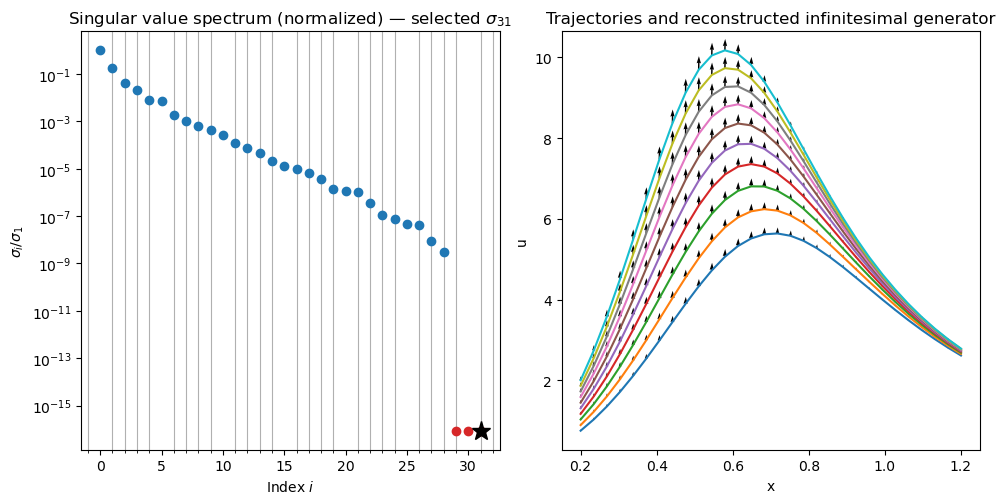

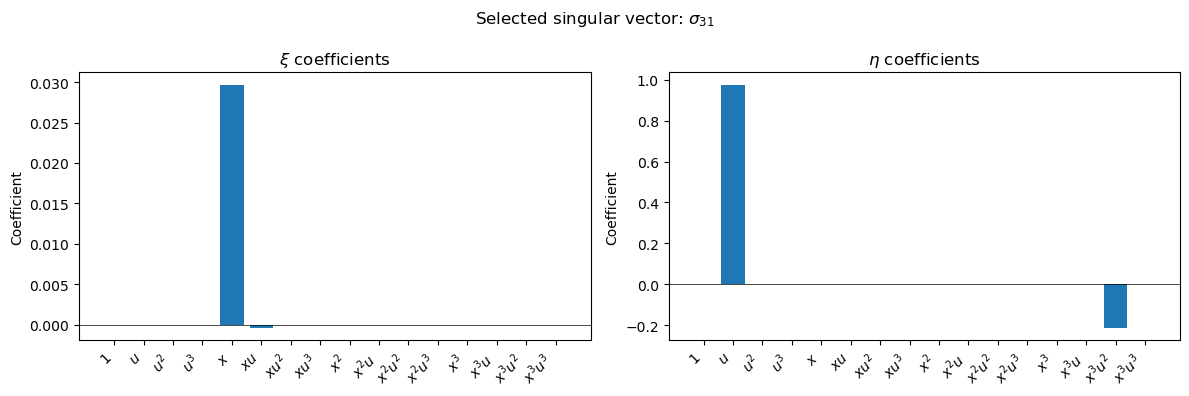

In [6]:
# Indexes into small_sv_idx, printed above (not an absolute S/Vt index).
# Out-of-range values are clamped to the nearest valid choice with a warning.
SV_CHOICE = 2

idx = solver.pick_small_singular_value(small_sv_idx, sv_choice=SV_CHOICE)
result = solver.select_singular_vector(svd_result, idx)
rpt.print_selection_summary(result.S, result.idx)

# Every plot below is derived from this one chosen singular vector.
sigma_label = rf"$\sigma_{{{result.idx}}}$"

# Same spectrum as above (fig3/ax3), on a new axis, with the chosen
# singular value starred.
fig4, ax4 = plt.subplots(1,2, figsize=(10, 5))

ax4[0].semilogy(large_sv_idx, S_norm[large_sv_idx], marker='o', linestyle='None', color='C0')
ax4[0].semilogy(small_sv_idx, S_norm[small_sv_idx], marker='o', linestyle='None', color='C3')
ax4[0].semilogy(result.idx, S_norm[result.idx], marker='*', markersize=14, linestyle='None', color='k', zorder=3)
ax4[0].set_xlabel("Index $i$")
ax4[0].set_ylabel(r"$\sigma_i / \sigma_1$")
ax4[0].set_title(f"Singular value spectrum (normalized) \u2014 selected {sigma_label}")
ax4[0].set_box_aspect(1)
ax4[0].grid(which='minor')
ax4[0].minorticks_on()

ax4[1].quiver(X_stacked[0], X_stacked[1], result.xi, result.eta, angles='xy', scale=20, scale_units='xy')
for trajectory in X:
    ax4[1].plot(trajectory[0], trajectory[1])
ax4[1].set_xlabel("x")
ax4[1].set_ylabel("u")
ax4[1].set_title("Trajectories and reconstructed infinitesimal generator")
ax4[1].set_box_aspect(1)

fig4.tight_layout()

# Coefficients
n_basis = len(result.param_list)

bars_fig, (ax_xi, ax_eta) = plt.subplots(1, 2, figsize=(12, 4))
bars_fig.suptitle(f"Selected singular vector: {sigma_label}")
plot.plot_basis_coefficient_bars(
    result.singular_vector[:n_basis], result.param_list, basis_args.basis_type,
    ax=ax_xi, title=r"$\xi$ coefficients", sort_by_magnitude=False, log_scale=False
)
plot.plot_basis_coefficient_bars(
    result.singular_vector[n_basis:], result.param_list, basis_args.basis_type,
    ax=ax_eta, title=r"$\eta$ coefficients", sort_by_magnitude=False, log_scale=False
)
bars_fig.tight_layout()

### Jet-space tangent field vs. analytic normal field

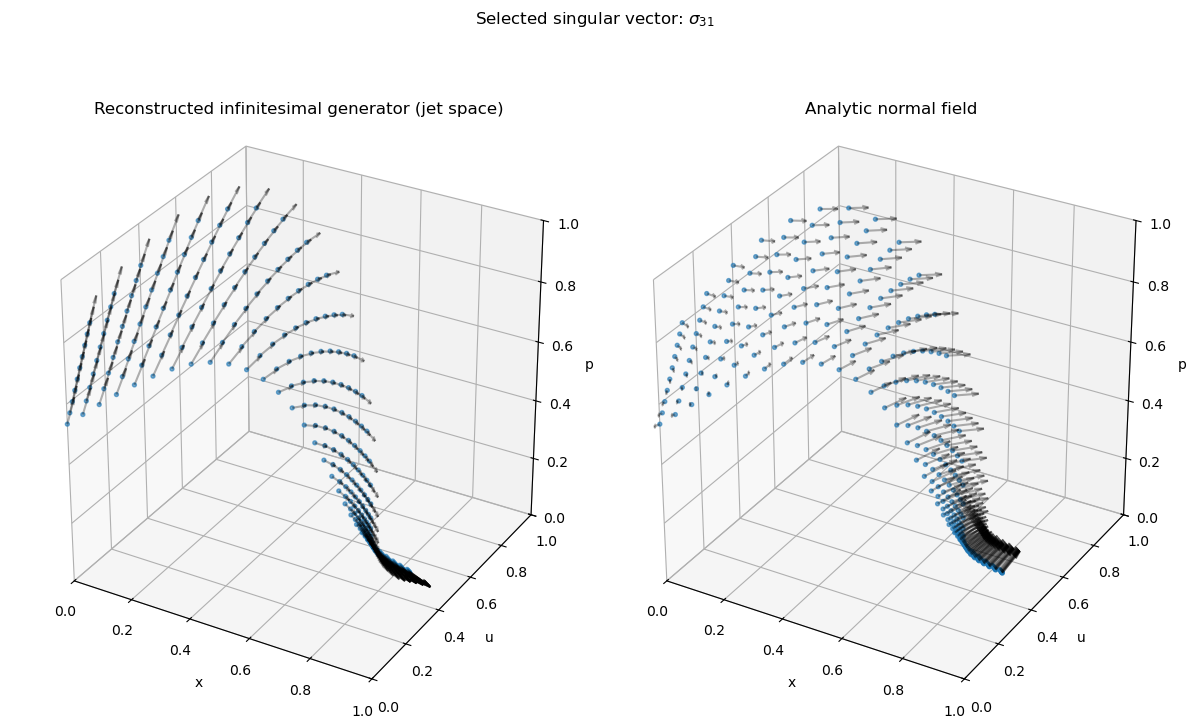

In [8]:
V = np.stack((result.xi, result.eta, result.zeta))

jet_fig, jet_ax = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(12, 8))
jet_fig.suptitle(f"Selected singular vector: {sigma_label}")
plot.scaled_3D_quiver(X_stacked, V, mode="tangent", ax=jet_ax[0])
jet_ax[0].set_title("Reconstructed infinitesimal generator (jet space)")
plot.scaled_3D_quiver(X_stacked, N, mode="normal", ax=jet_ax[1])
jet_ax[1].set_title("Analytic normal field")
jet_fig.tight_layout()